In [199]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA,KernelPCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.neighbors import NearestNeighbors,LocalOutlierFactor
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score

## **Mall Customer Segmentation System**

### Section - A (K-Means Clustering)

In [167]:
# Loading The Dataset
df = pd.read_csv("Mall_Customers_Dataset.csv")
df

,CustomerID,Genre,Age,Annual_Income_kUSD,Spending_Score,Purchase_Freq,Recency_days
0,1,Male,19,15,39,11,29
1,2,Male,21,15,81,1,71
2,3,Female,20,16,6,4,58
3,4,Female,23,16,77,3,27
4,5,Female,31,17,40,11,140
...,...,...,...,...,...,...,...
195,196,Female,25,91,55,5,12
196,197,Male,29,92,41,1,86
197,198,Female,26,92,55,3,68
198,199,Male,28,99,39,3,114


- From The Above Dataset You Can See That There Are Columns Which Contains Customer Information Collected From A Shopping Mall : "Cusomer_Id","Age","Genre","Annual Income","And Purchase Frequency".

- The Dataset Is Used For Clustering , Dimensionality Reduction, Anomaly Detection, And Recommendation System.

#### Q1

In [168]:
# Selecting Features 
x_kmeans = df[["Annual_Income_kUSD","Spending_Score"]]

- Income Tells The Purchasing Power
- Spending Score Tells Customer Behaviour

In [169]:
# Standardizing The Features Through Pipeline To Prevent Data Leakeage
preprocessing_pipeline = Pipeline([
    ("StandardScaler",StandardScaler())
])

preprocessing = ColumnTransformer([
    ("Preprocessing",preprocessing_pipeline,["Annual_Income_kUSD","Spending_Score"])
])

- Preprocessing The Data To Prevent Wrong Prediction Of Data Points Because Unusual High Values.

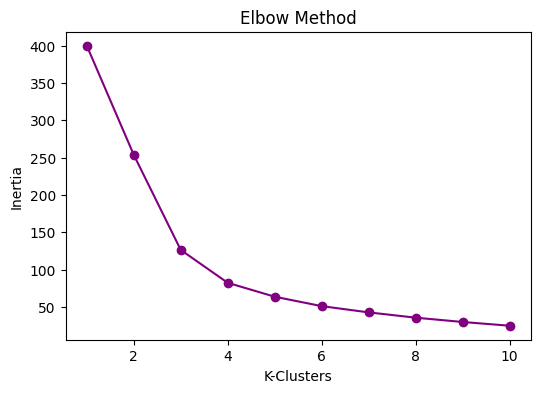

In [170]:
# Applying Elbow Method By Building A Pipeline
inertia = []
for i in range(1,11):
    inertia_model = Pipeline([
        ("preprocessing",preprocessing),
        ("algorithm",KMeans(n_clusters=i,random_state=42,n_init=10))
    ])
    inertia_model.fit(x_kmeans)
    inertia.append(inertia_model["algorithm"].inertia_)

# Ploting The Inertia Graph
plt.figure(figsize=(6,4))
plt.plot(range(1,11),inertia,marker="o",color="purple")
plt.title("Elbow Method")
plt.xlabel("K-Clusters")
plt.ylabel("Inertia")
plt.show()

- We Have Calculated Inertia Using Elbow Method. Now We Can See That In The Above Graph When The Line Starting Curving That Is The Point Of Cluster We Can Select For Prediction.

In [171]:
# Find The Sihouette Score Of Each Cluster And Show The Best Score
scores = []
for i in range(2,9):
    silhouette_pipeline = Pipeline([
        ("preprocessing",preprocessing),
        ("algorithm",KMeans(n_clusters=i,random_state=42,n_init=10))
    ])
    labels = silhouette_pipeline.fit_predict(x_kmeans)
    score = silhouette_score(x_kmeans,labels)
    scores.append(score)

# Showing The Highest Silhouette Score With The K-Value
best_k = range(2,9)[scores.index(max(scores))]
print(f"The K-Value {best_k} With The Silhouette Score Of {max(scores)} Has The Highest Score")

The K-Value 3 With The Silhouette Score Of 0.5712706736419195 Has The Highest Score


- From The Above It Can Be Determined That With K-Value 3 THe Silhouette Score Is The Highest So Limited Number Are More Efficient Than more Number Of Clusters.

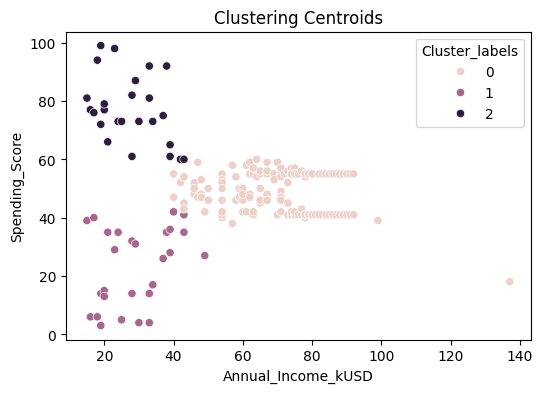

In [172]:
# Building The Final KMeans Model For Prediction With k=3
model_kmeans = Pipeline([
    ("preprocessing",preprocessing),
    ("algorithm",KMeans(n_clusters=3,random_state=42,n_init=10))
])
df["Cluster_labels"] = model_kmeans.fit_predict(x_kmeans)

# Ploting The Clusters With Centroids
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x="Annual_Income_kUSD",y="Spending_Score",hue="Cluster_labels")
plt.title("Clustering Centroids")
plt.show()

- From The Above Graph We Can See That KMeans Model Has Seperated Data Points Among 3 Groups And Also Measured It's Distance Using Euclidean.

#### Q2

In [173]:
# Printing All The Metric Values In An Formatted Comparison Table 
scores = []
for i in range(3,6):
    metric_pipeline = Pipeline([
        ("preprocessing",preprocessing),
        ("algorithm",KMeans(n_clusters=i,random_state=42,n_init=10))
    ])
    labels = metric_pipeline.fit_predict(x_kmeans)
    dbi = davies_bouldin_score(x_kmeans,labels)
    chi = calinski_harabasz_score(x_kmeans,labels)
    scores.append([i,dbi,chi])

In [174]:
# Creating The Formatted The Table
comparison = pd.DataFrame(scores,columns=["K","Davies-Bouldin Index","Calinski-Harabasz Score"])
comparison

,K,Davies-Bouldin Index,Calinski-Harabasz Score
0,3,0.590917,204.604541
1,4,0.677550,278.891291
2,5,0.730804,262.603129


- Daviss Bouldin Index : Lower Is Good 
- Calinski Harabasz Index : Higher Is Good

- So From The Above Table K=4 Is Better An Optimal For Both The Metric Values, Because It Has An Optimal Davis Bouldin Index But It Has Higher Calinski Harabasz Score.

### Section - B (Hierarchical Clustering & DBSCAN)

#### Q3

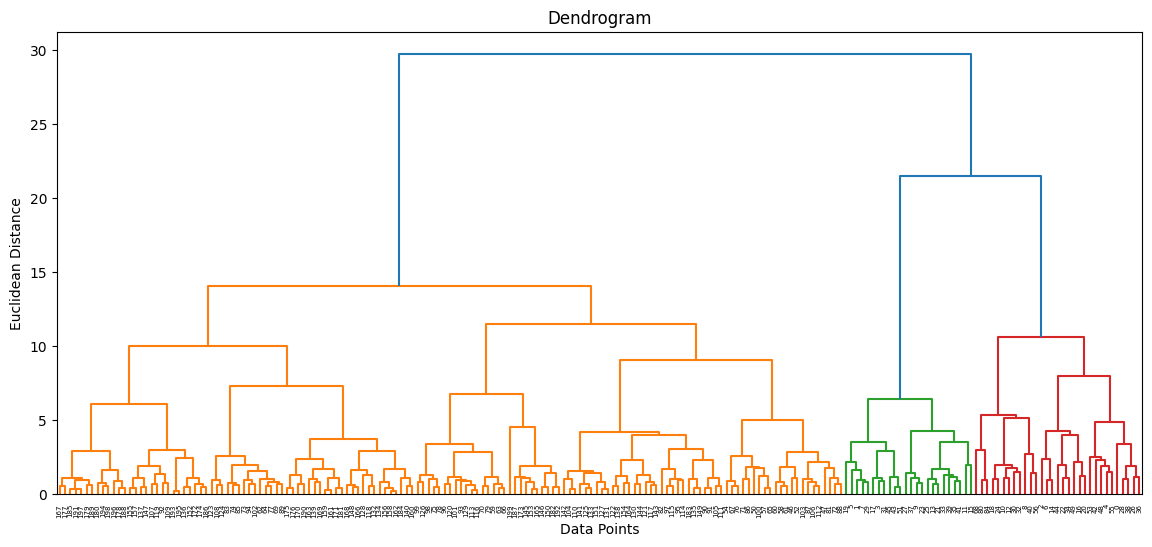

In [175]:
# Applying Agglomerative Hierarchical Clustering On All Numeric Features
numeric_df = df.select_dtypes(include="number")

# Applying Standard Scalar On This Features
numeric_scaled = StandardScaler().fit_transform(numeric_df)

# Computing Ward Linkage Matrix
linkage_matrix = linkage(numeric_scaled,method="ward")

# Plotting The Dendogram
plt.figure(figsize=(14,6))
dendrogram(linkage_matrix)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

- An Tree Based Structered Is Made In The Dendogram Because From Bottom Each Data Point Was Its Own Cluster But Eventually Linkage Method Measures Distance Between Clusters And Minimizes Variance.

In [176]:
# Cuting The Dendogram And Fitting it To The Agglomerative Model For Prediction
model_agglo = Pipeline([
    ("algorithm",AgglomerativeClustering(n_clusters=4,linkage="ward",metric="euclidean"))
])
agglo_labels = model_agglo.fit_predict(numeric_scaled)

# Performing The PCA To Visualize The Agglo Model
pca = PCA(n_components=2)
x_pca = pca.fit_transform(numeric_scaled)

# Fitting The KMeans Model For Comparison
model_kmeans1 = Pipeline([
    ("algorithm",KMeans(n_clusters=3,random_state=42,n_init=10))
])
kmeans_labels = model_kmeans1.fit_predict(numeric_scaled)

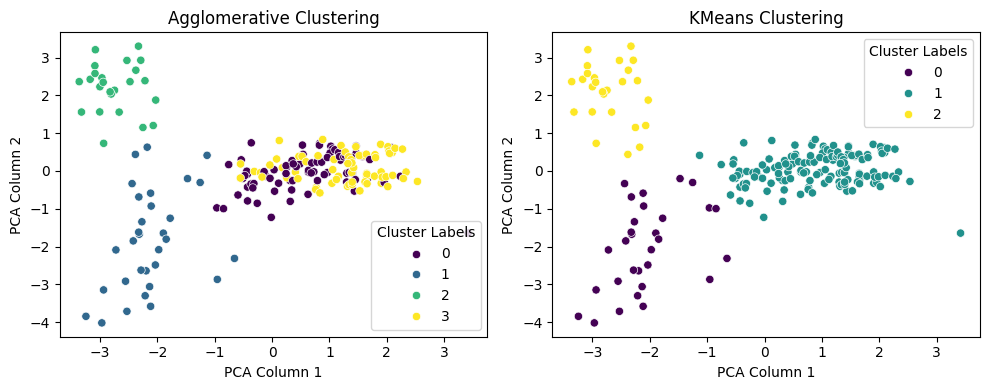

In [177]:
# Comparison Of Both Agglomerative And KMeans Clustering Models
fig, axes = plt.subplots(1, 2, figsize=(10,4))
# Agglomerative Clustering Plot
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=agglo_labels,palette="viridis",ax=axes[0])
axes[0].set_title("Agglomerative Clustering")
axes[0].legend(title="Cluster Labels")
axes[0].set_xlabel("PCA Column 1")
axes[0].set_ylabel("PCA Column 2")

# KMeans Clustering Plot
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=kmeans_labels,palette="viridis",ax=axes[1])
axes[1].set_title("KMeans Clustering")
axes[1].legend(title="Cluster Labels")
axes[1].set_xlabel("PCA Column 1")
axes[1].set_ylabel("PCA Column 2")
plt.tight_layout()
plt.show()

- From The Above Graph We Can See That Both Agglomerative Clustering And KMeans Produced Similar Customer Groupings, But Some Data Points Are Assigned Differently Because Hierarchical Clustering Used Linkage Distance While KMeans Uses CentroidBased Clustering.

#### Q4 
- Apply DBSCAN On The Scaled Dataset (Age, Annual Income, Spending Score)

In [178]:
# Selecting Features
dbscan_df =df[["Age","Annual_Income_kUSD","Spending_Score"]]

# Scaling Data Through Pipeline And Column Transformer To Avoid Data Leakeage
preprocessing_pipeline = Pipeline([
    ("StandardScaler",StandardScaler())
])
preprocessing = ColumnTransformer([
    ("Preprocessing",preprocessing_pipeline,["Age","Annual_Income_kUSD","Spending_Score"])
])

# Scaling The Data For Fiting It Into Nearest Neighbors Model
dbscan_df_scaled = preprocessing.fit_transform(dbscan_df)

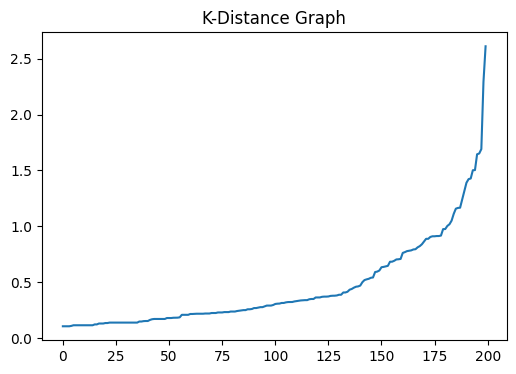

In [179]:
# Now We Will Apply K-Distance Graph(k=5)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(dbscan_df_scaled)
distances,indices = neighbors_fit.kneighbors(dbscan_df_scaled)

# Sorting  
distances = np.sort(distances[:,4])

# Plotting An K-Distance Graph
plt.figure(figsize=(6,4))
plt.title("K-Distance Graph")
plt.plot(distances)
plt.show()

- This Graph Shows Us Which Epsilon Values We Should Use For DBSCAN Model To Get Maximun Output

In [180]:
# Applying DBSCAN Model
model_dbscan =  Pipeline([
    ("dbscan",DBSCAN(eps=1.3,min_samples=14))
])
dbscan_labels = model_dbscan.fit_predict(dbscan_df_scaled)
print(f"Silhouette Score : {silhouette_score(dbscan_df_scaled,dbscan_labels):.2f}")

# Noise Data Points Counts
noise_counts = list(dbscan_labels).count(-1)
print(f"Noise Count : {noise_counts}")
print(f"Noise Count Percentage : {(noise_counts/len(dbscan_labels))*100} %")

Silhouette Score : 0.58
Noise Count : 16
Noise Count Percentage : 8.0 %


- DBSCAN Identified Noise Points Automatically Where K-Means Assigned Every Point To Cluster

- Advantage Of DBSCAN Is That It Performs Better For Irregular Shaped Clusters And Outliers Detection

### Section - C  (Dimensionality Reduction)

#### Q5

In [181]:
# Applying Principal Component Analysis On All Numeric Columns
preprocessing_pca = ColumnTransformer([
    ("preprocessing",preprocessing_pipeline,numeric_df.columns.tolist())
])

# Appyling PCA Model Through Pipeline
model_pca = Pipeline([
    ("preprocessing",preprocessing_pca),
    ("PCA",PCA())
])

x_pca = model_pca.fit_transform(numeric_df)

In [182]:
# Printing Explained Variance Ratio For Each Principal Component
for i,ratio in enumerate(model_pca["PCA"].explained_variance_ratio_,start=1):
    print(f"Principal Component {i} Has An Ratio Of : {ratio:.2f}")

Principal Component 1 Has An Ratio Of : 0.40
Principal Component 2 Has An Ratio Of : 0.22
Principal Component 3 Has An Ratio Of : 0.15
Principal Component 4 Has An Ratio Of : 0.14
Principal Component 5 Has An Ratio Of : 0.05
Principal Component 6 Has An Ratio Of : 0.04
Principal Component 7 Has An Ratio Of : 0.00


- Total Of 7 Components Where Made By The Model.

- This Explained Variance Ratio Demonstrates The Variance Of The Dataset Between Columns And With Each Component The Variance Decreases But The Final Evaluation Is Made Through Cumulative Addition Of All The Principal Components Which Gets To Total Of 1 Or Depending On The Dataset.

In [183]:
# Cumulative Addition Of Our Model_pca
np.cumsum(model_pca["PCA"].explained_variance_ratio_)

array([0.39650105, 0.6204144 , 0.76918252, 0.90587179, 0.9601132 ,
       0.99713264, 1.        ])

- Our Model Has An 1 Explained Variance Ratio In Total Which Is Very Good.

In [184]:
# Now We Will Apply Kernel PCA With Two Components And Visualize Results Coloured By K-Means Labels
# Applying Principal Component Analysis On All Numeric Columns
preprocessing_pca = ColumnTransformer([
    ("preprocessing",preprocessing_pipeline,numeric_df.columns.tolist())
])

# Appyling PCA Model Through Pipeline
model_pca_two = Pipeline([
    ("preprocessing",preprocessing_pca),
    ("KernalPCA",KernelPCA(n_components=2,kernel="rbf",random_state=42))
])

x_kpca = model_pca_two.fit_transform(numeric_df)

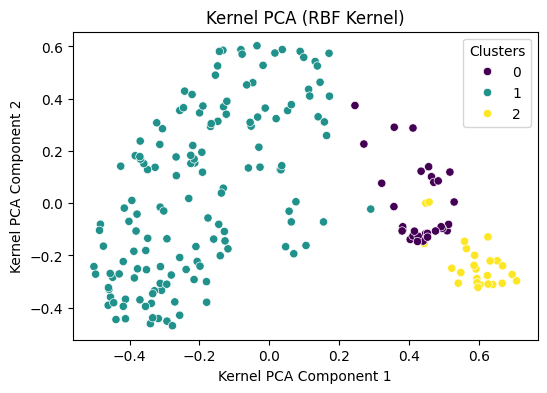

In [185]:
# Visualizing The PCA Model With Two Components
plt.figure(figsize=(6,4))
sns.scatterplot(x=x_kpca[:,0],y=x_kpca[:,1],hue=kmeans_labels,palette="viridis")
plt.title("Kernel PCA (RBF Kernel)")
plt.xlabel("Kernel PCA Component 1")
plt.ylabel("Kernel PCA Component 2")
plt.legend(title="Clusters")
plt.show()

- Kernel PCA transforms the data using a nonlinear RBF kernel. 

#### Q6

In [186]:
# Applying t-SNE On The Scaled Full Features Set (Parameter Details = [perplexcity=30,n_iter=1000])
model_tsne = Pipeline([
    ("preprocessing",preprocessing_pca), # Using The PCA Preprocessing As We Have To Find Out The Difference Between Them
    ("tsne",TSNE(n_components=2,perplexity=30,max_iter=1000,random_state=42))
])

tsne = model_tsne.fit_transform(numeric_df)   # We Are Using numeric_df As It Has All Numeric Features

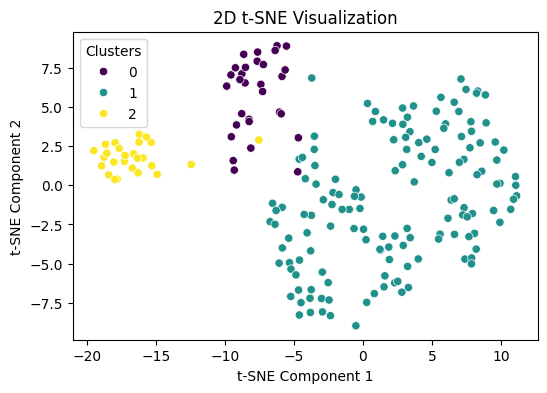

In [187]:
# Visualizing The t-SNE Model
plt.figure(figsize=(6,4))
sns.scatterplot(x=tsne[:,0],y=tsne[:,1],hue=kmeans_labels,palette="viridis")
plt.title("2D t-SNE Visualization")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Clusters")
plt.show()

- The t-SNE visualization shows a clear separation of customer clusters.
- It Shows Clusters Points Of Every Dimensions Into a 2d Plan Which is More Viable Visibly.

Difference Between PCA And t-SNE

- PCA Reduces Dimension Linearly But t-SNE Reduces Dimension Non-Linearly

- PCA Faster And t-SNE Is Slower

### Section - D (Anomaly Detection)

#### Q7

In [188]:
# Now We Will Apply Isolation Forest On All The Numeric Features With Comtamination Rate Of 0.05
preprocessing_anomaly = ColumnTransformer([
    ("preprocessing",preprocessing_pipeline,numeric_df.columns.tolist())
])

model_isolation = Pipeline([
    ("preprocessing",preprocessing_pca),
    ("Isolation Forest",IsolationForest(contamination=0.05,random_state=42))
])

isolation_labels = model_isolation.fit_predict(numeric_df)
isolation_labels

array([-1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1])

- Isolation Forest Isolates Observations As Normal Points Requires Many Points To Split But Outlier Reqiures Few Points To Splits.

- Here -1 Labels Indicates That It Is An Outlier And 1 Indicates It Is An Normal Data Point

In [189]:
# Counting How Many Anomalies Are There In The Model
anomaly_count = (isolation_labels == -1).sum()
print("Isolation Forest Anomalies:", anomaly_count)

Isolation Forest Anomalies: 10


- Isolation Forest Has A Total Of 10 Outliers With 0.05 Contamination Rate Which Fairly Good.

In [190]:
# Now We Will Apply Local Outlier Factor With n_neighbors Of 20
model_local_outlier = Pipeline([
    ("preprocessing",preprocessing_anomaly),
    ("Local Outlier Factor",LocalOutlierFactor(n_neighbors=20))
])

local_outlier_labels = model_local_outlier.fit_predict(numeric_df)
local_outlier_labels

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1])

In [191]:
# Counting How Many Anomalies Are There In The Model
anomaly_count = (local_outlier_labels == -1).sum()
print("Local Outliers Factor Anomalies:", anomaly_count)

Local Outliers Factor Anomalies: 2


- Local Outlier Factor Has A Total Of 2 Outliers Which Is Very Good With 20 n_neighbors.

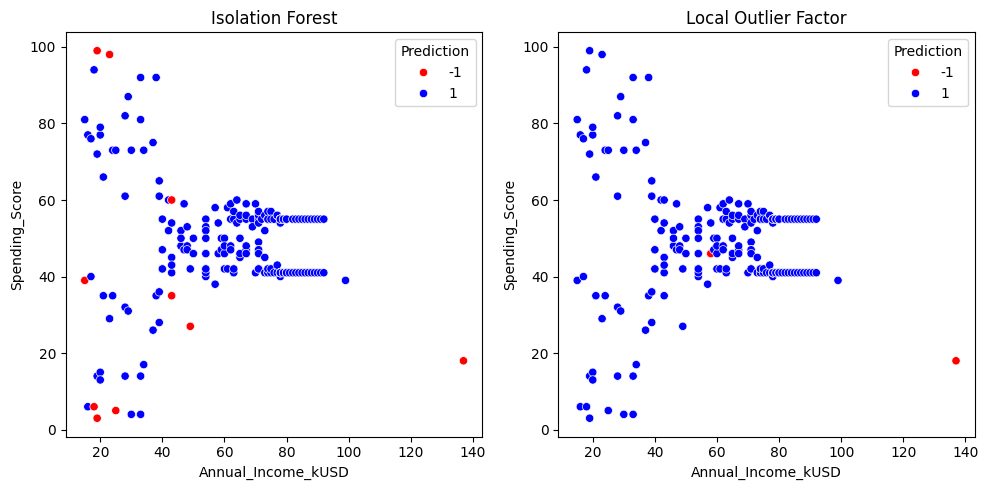

In [192]:
# Now We Will Visualize Both The Anomaly Models On A 2D Scatter Plot Using (Spending_score VS Annual Income)
# Isolation Forest
fig, axes = plt.subplots(1,2, figsize=(10,5))
sns.scatterplot(data=df,x="Annual_Income_kUSD",y="Spending_Score",hue=isolation_labels,palette={1:"blue",-1:"red"},ax=axes[0])
axes[0].set_title("Isolation Forest")
axes[0].legend(title="Prediction")

# Local Outlier Factor
sns.scatterplot(data=df,x="Annual_Income_kUSD",y="Spending_Score",hue=local_outlier_labels,palette={1:"blue",-1:"red"},ax=axes[1])
axes[1].set_title("Local Outlier Factor")
axes[1].legend(title="Prediction")
plt.tight_layout()
plt.show()

- From The Above We Cann See That In Isolation Forest There Are More Outliers(-1) Points Compared To Local Outlier Factor.

- Unusual Customer Behaviour Were Detected Because If An Person's Annual Income Is 60 USD But His Spending Is Greater Or Equal To 60 USD Which Is Classified As Outliers.

#### Q8

### Section - E (Recommendation Systems)

#### Q9

In [198]:
# Build a simple content-based recommendation system using the mall customer data.
recommend_df = df[["Age", "Annual_Income_kUSD", "Spending_Score"]]

# Scaling the data through pipeline
recommend_pipeline = Pipeline([
    ("StandardScaler", StandardScaler())
])

recommend_preprocessing = ColumnTransformer([
    ("preprocessing", recommend_pipeline, ["Age", "Annual_Income_kUSD", "Spending_Score"])
])

x_scaled = recommend_preprocessing.fit_transform(recommend_df)

In [227]:
# Computing Similarity Scores
similarity_matrix = cosine_similarity(x_scaled)

- Now Every Customer Is Compared With Every Other Customer Which Means Every Customers Vectors And There Similarity Scores Have Been Calculated In The Vectoe Space.

In [ ]:
# Getting The Similarity Scores Of All The Customer Id Based On Customer Index 5
customer_index = 4
similarity_scores = similarity_matrix[customer_index]
top3 = similarity_scores.argsort()[::-1][1:4]

In [231]:
# Showing The Top3 Customer Which Are Similar To Customer Index 5
for i in top3:
    print(f"Customer ID: {df.iloc[i]['CustomerID']}, Similarity: {similarity_scores[i]:.4f}")

Customer ID: 67, Similarity: 0.9975
Customer ID: 49, Similarity: 0.9838
Customer ID: 64, Similarity: 0.9723


- Skipped Question 10 Because We Have To Do Any 2 Attempts.

#### Q11